In [1]:
import numpy as np
import tensorflow as tf
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import random

In [2]:
# redefining const
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

data_dir = Path("data/Decks")

# load trained model
model = tf.keras.models.load_model("defect_model.keras")

In [3]:
def predict_defect(img_path, threshold=0.5):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    x = tf.keras.utils.img_to_array(img)
    x = tf.expand_dims(x, 0) 

    prob_defect = float(model.predict(x, verbose=0)[0][0])
    label = "defect" if prob_defect >= threshold else "no_defect"

    print(f"Image: {img_path}")
    print(f"Predicted probability of DEFECT: {prob_defect:.2%}")
    print(f"Predicted label: {label}")
    return label, prob_defect

In [4]:
def print_defect_probs(n=10):
    defect_folder = Path("data/Decks/defect")
    paths = list(defect_folder.glob("*.jpg"))[:n]
    for p in paths:
        _, prob = predict_defect(str(p))
        print("---")

print_defect_probs(10)

Image: data/Decks/defect/7047-226.jpg
Predicted probability of DEFECT: 100.00%
Predicted label: defect
---
Image: data/Decks/defect/7004-112.jpg
Predicted probability of DEFECT: 3.79%
Predicted label: no_defect
---
Image: data/Decks/defect/7020-4.jpg
Predicted probability of DEFECT: 98.15%
Predicted label: defect
---
Image: data/Decks/defect/7011-26.jpg
Predicted probability of DEFECT: 99.67%
Predicted label: defect
---
Image: data/Decks/defect/7002-194.jpg
Predicted probability of DEFECT: 6.10%
Predicted label: no_defect
---
Image: data/Decks/defect/7057-226.jpg
Predicted probability of DEFECT: 61.27%
Predicted label: defect
---
Image: data/Decks/defect/7002-66.jpg
Predicted probability of DEFECT: 19.44%
Predicted label: no_defect
---
Image: data/Decks/defect/7044-33.jpg
Predicted probability of DEFECT: 99.84%
Predicted label: defect
---
Image: data/Decks/defect/7009-119.jpg
Predicted probability of DEFECT: 23.72%
Predicted label: no_defect
---
Image: data/Decks/defect/7022-110.jpg
Pr

In [5]:
# generating test photos
def collect_probs_per_class(n_per_class=50):
    defect_paths = list(Path("data/Decks/defect").glob("*.jpg"))
    no_defect_paths = list(Path("data/Decks/no_defect").glob("*.jpg"))

    random.seed(42)
    defect_sample = random.sample(defect_paths, min(n_per_class, len(defect_paths)))
    no_defect_sample = random.sample(no_defect_paths, min(n_per_class, len(no_defect_paths)))

    records = []

    for p in defect_sample:
        _, prob = predict_defect(str(p), threshold=0.5)  # uses your existing function
        records.append({"path": str(p), "true_label": "defect", "prob_defect": prob})

    for p in no_defect_sample:
        _, prob = predict_defect(str(p), threshold=0.5)
        records.append({"path": str(p), "true_label": "no_defect", "prob_defect": prob})

    df_eval = pd.DataFrame(records)
    df_eval.head()
    return df_eval

df_eval = collect_probs_per_class(n_per_class=50)

Image: data/Decks/defect/7028-137.jpg
Predicted probability of DEFECT: 36.25%
Predicted label: no_defect
Image: data/Decks/defect/7048-114.jpg
Predicted probability of DEFECT: 26.77%
Predicted label: no_defect
Image: data/Decks/defect/7046-196.jpg
Predicted probability of DEFECT: 99.99%
Predicted label: defect
Image: data/Decks/defect/7020-83.jpg
Predicted probability of DEFECT: 100.00%
Predicted label: defect
Image: data/Decks/defect/7048-93.jpg
Predicted probability of DEFECT: 1.57%
Predicted label: no_defect
Image: data/Decks/defect/7009-152.jpg
Predicted probability of DEFECT: 14.47%
Predicted label: no_defect
Image: data/Decks/defect/7036-134.jpg
Predicted probability of DEFECT: 27.33%
Predicted label: no_defect
Image: data/Decks/defect/7010-108.jpg
Predicted probability of DEFECT: 6.89%
Predicted label: no_defect
Image: data/Decks/defect/7033-190.jpg
Predicted probability of DEFECT: 3.63%
Predicted label: no_defect
Image: data/Decks/defect/7028-159.jpg
Predicted probability of DE

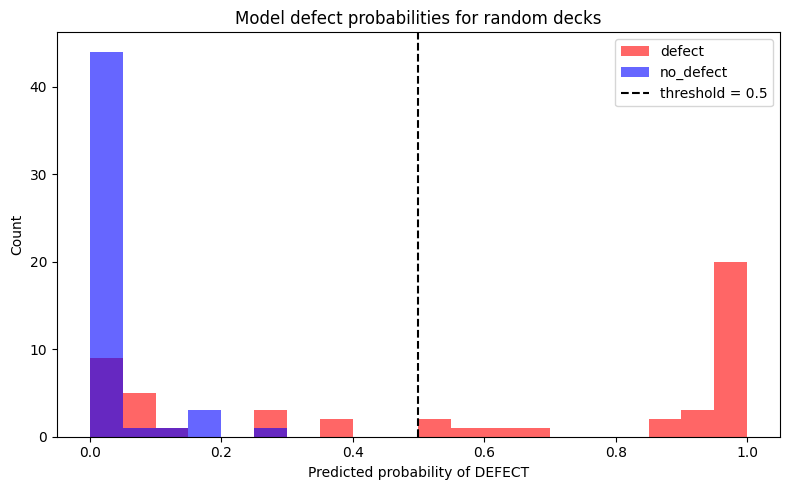

In [6]:
plt.figure(figsize=(8, 5))

for label, color in [("defect", "red"), ("no_defect", "blue")]:
    subset = df_eval[df_eval["true_label"] == label]["prob_defect"]
    plt.hist(
        subset,
        bins=20,
        alpha=0.6,
        label=label,
        color=color,
        range=(0.0, 1.0),
    )

plt.axvline(0.5, color="black", linestyle="--", label="threshold = 0.5")
plt.xlabel("Predicted probability of DEFECT")
plt.ylabel("Count")
plt.title("Model defect probabilities for random decks")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
df_eval.groupby("true_label")["prob_defect"].describe()

,count,mean,std,min,25%,50%,75%,max
true_label,,,,,,,,
defect,50.0,0.593644,0.419354,5.096192e-04,0.093771,0.788645,0.998799,1.000000
no_defect,50.0,0.025800,0.053269,1.590059e-09,0.000899,0.005586,0.018500,0.260546


In [8]:
# Test different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for thresh in thresholds:
    df_eval[f"pred_label_{thresh}"] = (df_eval["prob_defect"] >= thresh).astype(int)
    recall = recall_score(df_eval["true_label_int"], df_eval[f"pred_label_{thresh}"])
    precision = precision_score(df_eval["true_label_int"], df_eval[f"pred_label_{thresh}"])
    print(f"Threshold {thresh}: Recall={recall:.3f}, Precision={precision:.3f}")

NameError: name 'recall_score' is not defined